In [2]:
import sys
from pathlib import Path

sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))
# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle

In [3]:
# example_posdf = pd.read_csv(r'pos_dfs\0_circular_layout.csv')
# with open('graph_objects\graph_0.pkl', 'rb') as f:
#     G = pickle.load(f)

In [4]:
# zrobic df gdzie jest: graph_id+layout(czyli nazwa pliku), score, i oliczone wartosci kazdego z komponentow

# MAIN LOOP

In [6]:

# annotations = pd.read_excel('randoms_ER_annotations_scores.xlsx')
annotations = pd.read_excel('RGG_annotations_scores.xlsx')

In [8]:
import os 
posdf_dir = 'pos_dfs'
graph_dir = 'graph_objects'


calculated_components_df = pd.DataFrame(columns=['posdf_id', 'score', 
                                                 'node_distribution', 'node_distribution_raw', 
                                                 'distance_to_borderlines', 'distance_to_borderlines_raw', 
                                                 'edge_length_sum', 'edge_length_sum_raw', 
                                                 'edge_node_distance_contribution','edge_node_distance_contribution_raw', 
                                                 'count_edge_crossings',  'count_edge_crossings_raw',
                                                 'communities_closeness', 'sum_of_angles', 'symmetry'])

# Iterate through files in the posdf_dir
skip_layouts = ['lgl']


for posdf_file in os.listdir(posdf_dir):

    if posdf_file.split('_')[1].split('.')[0] not in skip_layouts:
        # reading data

        if posdf_file.endswith('.csv'):
            posdf = pd.read_csv(os.path.join(posdf_dir, posdf_file))
            print(f'Loaded {posdf_file}')

        graph_id = posdf_file.split('_')[0]
        layout = posdf_file.split('.')[0]
        if int(graph_id) < 10:
            layout = layout[2:]
        else:
            layout = layout[3:]
        score = annotations[annotations['graph_id'] == int(graph_id)][layout].values[0]


        graph_file = 'graph_' + graph_id + '.pkl' 
        with open(os.path.join(graph_dir, graph_file), 'rb') as f:
            G = pickle.load(f)
        components_dict = {
            'posdf_id': posdf_file,
            'score': score,
            'node_distribution': node_distribution(posdf),
            'node_distribution_raw': node_distribution_raw(posdf),
            'distance_to_borderlines': distance_to_borderlines(posdf),
            'distance_to_borderlines_raw': distance_to_borderlines_raw(posdf),
            'edge_length_sum': edge_length_sum(G, posdf),
            'edge_length_sum_raw': edge_length_sum_raw(G, posdf),
            'edge_node_distance_contribution': edge_node_distance_contribution(G, posdf)[0],
            'edge_node_distance_contribution_raw': edge_node_distance_contribution_raw(G, posdf)[0],

            'count_edge_crossings': count_edge_crossings(G, posdf),
            'count_edge_crossings_raw': count_edge_crossings_raw(G, posdf),

            'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
            'sum_of_angles' : sum_of_angles(G, posdf),
            'symmetry' : measure_graph_symmetry(G, posdf)
        }
        new_row_df = pd.DataFrame([components_dict])
        calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)

Loaded 0_kamada_kawai.csv
Loaded 0_pos from RGG.csv
Loaded 0_random_no1.csv
Loaded 0_random_no2.csv
Loaded 0_random_no3.csv
Loaded 0_random_no4.csv
Loaded 10_kamada_kawai.csv
Loaded 10_pos from RGG.csv
Loaded 10_random_no1.csv
Loaded 10_random_no2.csv
Loaded 10_random_no3.csv
Loaded 10_random_no4.csv
Loaded 11_kamada_kawai.csv
Loaded 11_pos from RGG.csv
Loaded 11_random_no1.csv
Loaded 11_random_no2.csv
Loaded 11_random_no3.csv
Loaded 11_random_no4.csv
Loaded 12_kamada_kawai.csv
Loaded 12_pos from RGG.csv
Loaded 12_random_no1.csv
Loaded 12_random_no2.csv
Loaded 12_random_no3.csv
Loaded 12_random_no4.csv
Loaded 13_kamada_kawai.csv
Loaded 13_pos from RGG.csv
Loaded 13_random_no1.csv
Loaded 13_random_no2.csv
Loaded 13_random_no3.csv
Loaded 13_random_no4.csv
Loaded 14_kamada_kawai.csv
Loaded 14_pos from RGG.csv
Loaded 14_random_no1.csv
Loaded 14_random_no2.csv
Loaded 14_random_no3.csv
Loaded 14_random_no4.csv
Loaded 15_kamada_kawai.csv
Loaded 15_pos from RGG.csv
Loaded 15_random_no1.csv
Loa

In [9]:
calculated_components_df.head(10)

,posdf_id,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry
0,0_kamada_kawai.csv,5,123.255472,58.447663,10037.928,128.972,5.038862,5.334336,333.179496,100.525774,1,1,9.332476,1.496723,0.917901
1,0_pos from RGG.csv,6,508.657244,63.298585,40153.747,435.867,0.995865,2.259137,60.773966,47.806162,0,0,13.525991,2.062436,0.889906
2,0_random_no1.csv,1,760.664663,136.150053,227.109,52.764,2.649332,3.825668,716144.912610,1163.302320,36,6,4.472770,1.478962,0.976205
3,0_random_no2.csv,4,235.574225,91.430294,1182.728,82.072,2.190980,3.422565,738.441840,151.292654,4,2,5.757073,0.966006,0.991529
4,0_random_no3.csv,3,290.806236,101.164161,4324.703,110.488,2.791103,4.008539,7189.488063,311.022290,25,5,4.093229,1.789638,0.977913
5,0_random_no4.csv,2,1401.969452,161.000341,331.927,57.722,1.872527,2.692762,20494.250790,453.411608,1,1,5.741211,1.516964,0.989719
6,10_kamada_kawai.csv,3,113.140731,61.881439,10022.263,124.871,1.695332,2.604098,6904.597943,151.461029,1,1,2.272570,0.409981,0.958887
7,10_pos from RGG.csv,6,86.635174,49.962381,40075.800,431.676,0.423933,1.273030,88.153955,41.070202,0,0,4.318146,0.376774,0.951096
8,10_random_no1.csv,2,760.664663,136.150053,227.109,52.764,2.234770,2.698029,2458.524058,189.458804,0,0,1.606958,0.377838,0.976205
9,10_random_no2.csv,5,235.574225,91.430294,1182.728,82.072,2.161041,2.805941,611.985024,116.473813,0,0,1.074554,0.414576,0.991529


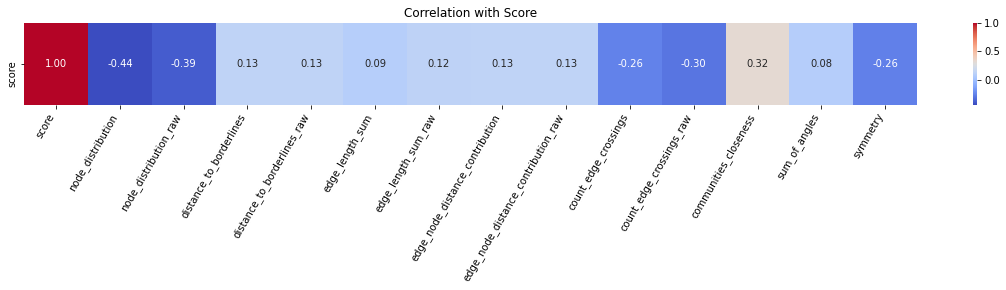

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'calculated_components_df' is already defined
calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])

# Calculate the correlation matrix
correlation_matrix = calculated_components_df_numeric.corr()

# Extract the correlation of all values to 'score'
score_correlation = correlation_matrix.loc[['score']]

# Generate a heatmap for the 'score' correlation
plt.figure(figsize=(20, 1.5))  # Adjust the figure size as needed
sns.heatmap(score_correlation, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')

plt.title('Correlation with Score')
plt.show()